## Семинар 3. Культуромика и API НКРЯ

Сегодня мы научимся работать с **Национальным корпусом русского языка** программно — через API. Это позволит нам воспроизвести подход Бонч-Осмоловской из статьи «Имена времени».

**План:**
1. Знакомимся с форматом JSON и учимся «раскапывать» вложенные структуры.
2. Подключаемся к API НКРЯ: статистика, портрет слова, конкордансы.
3. Воспроизводим исследование: конструкция «прилагательное + десятилетие».

In [1]:
# Импорты
import requests
import json
import time
import pandas as pd
import matplotlib.pyplot as plt

---


В статье Бонч-Осмоловской данные получены именно так: запрос к НКРЯ на конструкцию «прилагательное + порядковое числительное». Мы воспроизведём этот подход программно.

Главный справочный документ: [инструкция](https://ruscorpora.github.io/public-api/).

Чтобы обращаться к серверу НКРЯ, нужно научиться работать с файлами формата json.


## JSON 

*JSON** (*JavaScript Object Notation*) – простой, основанный на использовании текста, способ хранить и передавать структурированные данные.

Его придумали для того, чтобы упростить обмен данными.

Его предложения легко читаются и составляются как человеком, так и компьютером.

Его легко преобразовать в структуру данных для большинства языков программирования (числа, строки, логические переменные, массивы и так далее).

Многие языки программирования имеют функции и библиотеки для чтения и создания структур JSON.

JSON обычно более компактный чем XML.

#### Правила JSON

Строка JSON может содержать __объект__, и тогда она начинается с `{` и заканчивается на `}`. Такой объект очень похож на питоновский *словарь*: у него есть ключи – строки, которые пишутся в кавычках, а через двоеточие пишется значение, пары ключ-значение разделяются запятыми.

Значение в массиве или объекте может быть:
* Числом (целым или с плавающей точкой)
* Строкой (в двойных кавычках)
* Логическим значением (true или false)
* Другим массивом (заключенным в квадратные скобки)
* Другим объектом (заключенным в фигурные скобки)
* Значением null

Чтобы включить в строку специальные символы (например, кавычку), их нужно экранировать с помощью `\`, например, `\"` или `\r\n`. Наглядные правила построения JSON-строки можно посмотреть на [официальном сайте](http://www.json.org/), если захочется.

Может показаться, что это вообще-то все и так очень похоже на обычный питон. Но это не так. Во-первых, JSON – это не исполняемый код, а просто текст. Во-вторых, очень часто запись валидного питоновского словаря или массива не будет являться валидной записью в формате JSON. <br>Например, это не JSON, но при этом словарь: `{(1, 'a'): u'12345'}`.


Пример строки json:
```json
{"organisation": "Python Software Foundation",
 "officers": [
            {"first_name": "Guido", "last_name":"Rossum", "position":"president"},
            {"first_name": "Diana", "last_name":"Clarke", "position":"chair"},
            {"first_name": "Naomi", "last_name":"Ceder", "position":"vice chair"},
            {"first_name": "Van", "last_name":"Lindberg", "position":"vice chair"},
            {"first_name": "Ewa", "last_name":"Jodlowska", "position":"director of operations"}
            ],
"type": "non-profit",
"country": "USA",
"founded": 2001,
"members": 244,
"budget": 750000,
"url": "www.python.org/psf/"}
```

#### Как перемещаться по структуре вложенного словаря?


In [ ]:
# Пример: вложенный словарь 
example = {
    "student": {
        "name": "Алиса",
        "courses": ["история", "философия"],
        "grades": {"история": 9, "философия": 8}
    }
}

# Как добраться до оценки по истории?
# Шаг за шагом: словарь -> ключ -> ключ -> ключ
print(example["student"])                    # весь словарь студента
print(example["student"]["name"])            # "Алиса"
print(example["student"]["courses"][0])      # "история" (первый элемент списка)
print(example["student"]["grades"]["история"])  # 9

{'name': 'Алиса', 'courses': ['история', 'философия'], 'grades': {'история': 9, 'философия': 8}}
Алиса
история
9


В Python для работы с JSON используется модуль `json`.


#### Модуль `json`
Для чтения в модуле json есть два метода:
- `json.load()` – метод считывает **файл** в формате JSON и возвращает объекты Python. У этой функции один обязательный аргумент – файл.
- `json.loads()` – метод считывает **строку** в формате JSON и возвращает объекты Python. У этой функции один обязательный аргумент – строка.


Для записи информации в формате JSON в модуле `json` также два метода:
- `json.dump()` – метод **записывает объект Python в файл** в формате JSON. У этой функции два обязательных аргумента – файл и объект питона.
- `json.dumps()` – **превращает** питоновский словарь или массив **в строку JSON**. У этой функции один обязательный аргумент – словарь или массив.

## ЧАСТЬ 1
## Первый запрос: общая статистика по корпусу


#### requests.get() отправляет HTTP GET-запрос.

``` python
response = requests.get(f"{BASE_URL}/stats/", 
                        params=params, 
                        headers=HEADERS)
```
В запросе есть три аргумента:
1) URL — адрес эндпоинта. 
Эндпоинт — это конкретный URL-адрес, по которому приложение (клиент) обращается к серверу для получения или отправки данных через API. 

In [7]:
# Базовый URL — все запросы к API начинаются с этого адреса
BASE_URL = "https://ruscorpora.ru/api/v1"

2) params — параметры, которые добавятся к URL после знака "?" 

In [8]:
params = {"corpus": json.dumps({"type": "MAIN"})}
# Параметры запроса передаются как JSON-строка.
# {"type": "MAIN"} — основной корпус НКРЯ.
# Другие варианты: "PAPER" (газетный), "PARA" (параллельный) и др.

3. headers — заголовки запроса (у нас там токен авторизации)

In [ ]:
# Вставьте свой токен ниже:
API_TOKEN = ""  
# !!! НЕ публикуйте токен на GitHub !!!

# Заголовок авторизации — он будет добавляться к каждому запросу
HEADERS = {"Authorization": f"Bearer {API_TOKEN}"}

In [22]:
response = requests.get(f"{BASE_URL}/stats/", 
                        params=params, 
                        headers=HEADERS)

# response.status_code — числовой код ответа сервера:
#   200 = всё хорошо, данные получены
#   401 = не авторизован (проверьте токен)
#   400 = ошибка в параметрах запроса
#   500 = ошибка на стороне сервера
print(response)
print(response.text)

<Response [200]>
{"corpus": {"type": "MAIN", "lang": null}, "vals": {"textCount": 133554, "sentenceCount": 31626104, "wordUsageCount": 389471513}, "subStats": [{"disamb": ["MANUALLY_DISAMB"], "vals": {"textCount": 2164, "sentenceCount": 514169, "wordUsageCount": 5988177}}]}


In [23]:
# response.json() — превращаем текст ответа обратно в словарь Python.
stats = response.json()

# json.dumps(..., indent=2) — красиво печатаем с отступами.
# ensure_ascii=False — чтобы кириллица отображалась нормально, а не как \u0410.
print(json.dumps(stats, indent=2, ensure_ascii=False))

{
  "corpus": {
    "type": "MAIN",
    "lang": null
  },
  "vals": {
    "textCount": 133554,
    "sentenceCount": 31626104,
    "wordUsageCount": 389471513
  },
  "subStats": [
    {
      "disamb": [
        "MANUALLY_DISAMB"
      ],
      "vals": {
        "textCount": 2164,
        "sentenceCount": 514169,
        "wordUsageCount": 5988177
      }
    }
  ]
}


## Портрет слова (анализ лексемы)


In [27]:
# Здесь параметр называется query (а не corpus) и содержит больше полей.
query = json.dumps({
    "lemma": "дорога",                   # лемма — начальная форма слова
    "corpus": {"type": "MAIN"},          # в каком корпусе искать
    "seed": 12345,                       # число для воспроизводимости (как random seed)
    "resultType": ["PORTRAIT_WORD_INFO"] # какой тип информации вернуть
})

# Обратите внимание: params={"query": query} — мы передаём JSON-строку
# как значение параметра query в URL.
response = requests.get(
    f"{BASE_URL}/word-portrait/",
    params={"query": query},
    headers=HEADERS
)
print(response)

portrait = response.json()

<Response [200]>


In [42]:
portrait # итак посмотрим на этот ~~кровавый кошмар~~ ответ сервера

{'possiblePos': ['S', 'A'],
 'propsData': {'items': [{'parsingFields': [{'name': 'text',
      'value': [{'valString': {'v': 'дорога'}}],
      'level': 'ATTR_LEVEL_WORD'},
     {'name': 'lex',
      'value': [{'valString': {'v': 'дорога'}}],
      'level': 'ATTR_LEVEL_PARSING',
      'externalUrl': 'https://academic.ru/searchall.php?SWord=%D0%B4%D0%BE%D1%80%D0%BE%D0%B3%D0%B0'},
     {'name': 'gr',
      'value': [{'valString': {'v': 'существительное'}},
       {'valString': {'v': 'женский (род)'}},
       {'valString': {'v': 'неодушевленное'}}],
      'level': 'ATTR_LEVEL_PARSING'},
     {'name': 'sem',
      'value': [{'valString': {'v': 'r:concr'}},
       {'valString': {'v': 't:space'}},
       {'valString': {'v': '[SEP]'}}],
      'level': 'ATTR_LEVEL_PARSING'}]},
   {'parsingFields': [{'name': 'text',
      'value': [{'valString': {'v': 'дорога'}}],
      'level': 'ATTR_LEVEL_WORD'},
     {'name': 'lex',
      'value': [{'valString': {'v': 'дорога'}}],
      'level': 'ATTR_LEVEL_

In [43]:
portrait.keys()

dict_keys(['possiblePos', 'propsData'])

`possiblePos` — какая часть речи предполагается


In [ ]:
portrait['possiblePos'] 

['S', 'A']

In [ ]:
portrait['propsData'] 

{'items': [{'parsingFields': [{'name': 'text',
     'value': [{'valString': {'v': 'дорога'}}],
     'level': 'ATTR_LEVEL_WORD'},
    {'name': 'lex',
     'value': [{'valString': {'v': 'дорога'}}],
     'level': 'ATTR_LEVEL_PARSING',
     'externalUrl': 'https://academic.ru/searchall.php?SWord=%D0%B4%D0%BE%D1%80%D0%BE%D0%B3%D0%B0'},
    {'name': 'gr',
     'value': [{'valString': {'v': 'существительное'}},
      {'valString': {'v': 'женский (род)'}},
      {'valString': {'v': 'неодушевленное'}}],
     'level': 'ATTR_LEVEL_PARSING'},
    {'name': 'sem',
     'value': [{'valString': {'v': 'r:concr'}},
      {'valString': {'v': 't:space'}},
      {'valString': {'v': '[SEP]'}}],
     'level': 'ATTR_LEVEL_PARSING'}]},
  {'parsingFields': [{'name': 'text',
     'value': [{'valString': {'v': 'дорога'}}],
     'level': 'ATTR_LEVEL_WORD'},
    {'name': 'lex',
     'value': [{'valString': {'v': 'дорога'}}],
     'level': 'ATTR_LEVEL_PARSING',
     'externalUrl': 'https://academic.ru/searchall.php

In [33]:
portrait['propsData']['items'] # заглянём в список словарей-разборов

[{'parsingFields': [{'name': 'text',
    'value': [{'valString': {'v': 'дорога'}}],
    'level': 'ATTR_LEVEL_WORD'},
   {'name': 'lex',
    'value': [{'valString': {'v': 'дорога'}}],
    'level': 'ATTR_LEVEL_PARSING',
    'externalUrl': 'https://academic.ru/searchall.php?SWord=%D0%B4%D0%BE%D1%80%D0%BE%D0%B3%D0%B0'},
   {'name': 'gr',
    'value': [{'valString': {'v': 'существительное'}},
     {'valString': {'v': 'женский (род)'}},
     {'valString': {'v': 'неодушевленное'}}],
    'level': 'ATTR_LEVEL_PARSING'},
   {'name': 'sem',
    'value': [{'valString': {'v': 'r:concr'}},
     {'valString': {'v': 't:space'}},
     {'valString': {'v': '[SEP]'}}],
    'level': 'ATTR_LEVEL_PARSING'}]},
 {'parsingFields': [{'name': 'text',
    'value': [{'valString': {'v': 'дорога'}}],
    'level': 'ATTR_LEVEL_WORD'},
   {'name': 'lex',
    'value': [{'valString': {'v': 'дорога'}}],
    'level': 'ATTR_LEVEL_PARSING',
    'externalUrl': 'https://academic.ru/searchall.php?SWord=%D0%B4%D0%BE%D1%80%D0%BE%D

In [48]:
# `portrait['propsData']['items']` - список
# значит, можем пробежаться по нему циклом

for item in portrait['propsData']['items']:
    print(item) 

{'parsingFields': [{'name': 'text', 'value': [{'valString': {'v': 'дорога'}}], 'level': 'ATTR_LEVEL_WORD'}, {'name': 'lex', 'value': [{'valString': {'v': 'дорога'}}], 'level': 'ATTR_LEVEL_PARSING', 'externalUrl': 'https://academic.ru/searchall.php?SWord=%D0%B4%D0%BE%D1%80%D0%BE%D0%B3%D0%B0'}, {'name': 'gr', 'value': [{'valString': {'v': 'существительное'}}, {'valString': {'v': 'женский (род)'}}, {'valString': {'v': 'неодушевленное'}}], 'level': 'ATTR_LEVEL_PARSING'}, {'name': 'sem', 'value': [{'valString': {'v': 'r:concr'}}, {'valString': {'v': 't:space'}}, {'valString': {'v': '[SEP]'}}], 'level': 'ATTR_LEVEL_PARSING'}]}
{'parsingFields': [{'name': 'text', 'value': [{'valString': {'v': 'дорога'}}], 'level': 'ATTR_LEVEL_WORD'}, {'name': 'lex', 'value': [{'valString': {'v': 'дорога'}}], 'level': 'ATTR_LEVEL_PARSING', 'externalUrl': 'https://academic.ru/searchall.php?SWord=%D0%B4%D0%BE%D1%80%D0%BE%D0%B3%D0%B0'}, {'name': 'gr', 'value': [{'valString': {'v': 'существительное'}}, {'valString

In [ ]:
# посмотрим на первый из items
# снова в нашем распоряжении словарь, снова пробежимся по ключам: оказывается, что ключ один

portrait['propsData']['items'][0].keys()

dict_keys(['parsingFields'])

In [64]:
portrait['propsData']['items'][0]['parsingFields']

[{'name': 'text',
  'value': [{'valString': {'v': 'дорога'}}],
  'level': 'ATTR_LEVEL_WORD'},
 {'name': 'lex',
  'value': [{'valString': {'v': 'дорога'}}],
  'level': 'ATTR_LEVEL_PARSING',
  'externalUrl': 'https://academic.ru/searchall.php?SWord=%D0%B4%D0%BE%D1%80%D0%BE%D0%B3%D0%B0'},
 {'name': 'gr',
  'value': [{'valString': {'v': 'существительное'}},
   {'valString': {'v': 'женский (род)'}},
   {'valString': {'v': 'неодушевленное'}}],
  'level': 'ATTR_LEVEL_PARSING'},
 {'name': 'sem',
  'value': [{'valString': {'v': 'r:concr'}},
   {'valString': {'v': 't:space'}},
   {'valString': {'v': '[SEP]'}}],
  'level': 'ATTR_LEVEL_PARSING'}]

In [71]:
# Давайте напишем небольшой парсер на основе выдачи запроса

def parse_portrait(portrait):

    options = {}
    for i, block in enumerate(portrait['propsData']['items'], 1):
        razbor = {}

        for item in block['parsingFields']:
            name = item["name"]
            
            values = []
            for value in item['value']:
                values.append(value['valString']['v'])

            razbor[name] = values
            options[i] = razbor
    
    return options

In [72]:
parsed_items = parse_portrait(portrait)

parsed_items # в таком виде уже как-то поприятнее, без всяких лишних тегов

{1: {'text': ['дорога'],
  'lex': ['дорога'],
  'gr': ['существительное', 'женский (род)', 'неодушевленное'],
  'sem': ['r:concr', 't:space', '[SEP]']},
 2: {'text': ['дорога'],
  'lex': ['дорога'],
  'gr': ['существительное', 'неодушевленное', 'мужской (род)'],
  'sem': ['r:concr', 't:space', '[SEP]']},
 3: {'text': ['дорога'],
  'lex': ['дорога'],
  'gr': ['существительное', 'одушевленное', 'мужской (род)'],
  'sem': ['r:concr', 't:space', '[SEP]']},
 4: {'text': ['дорога'],
  'lex': ['Дорога'],
  'gr': ['существительное', 'одушевленное', 'женский (род)', 'имя'],
  'sem': ['r:concr', 't:space', '[SEP]']},
 5: {'text': ['дорога'],
  'lex': ['дорога'],
  'gr': ['существительное', 'одушевленное', 'женский (род)'],
  'sem': ['r:concr', 't:space', '[SEP]']}}

#### Задание 1

Напишите запрос к Портрету слова НКРЯ для любого слова на ваш выбор. Выведите все разборы через `parse_portrait`.

In [157]:
# ВАШ КОД ЗАПРОСА
# Здесь параметр называется query (а не corpus) и содержит больше полей.
query = json.dumps({
    "lemma": "течь",                   # лемма — начальная форма слова
    "corpus": {"type": "MAIN"},          # в каком корпусе искать
    "seed": 12345,                       # число для воспроизводимости (как random seed)
    "resultType": ["PORTRAIT_WORD_INFO"] # какой тип информации вернуть
})

# Обратите внимание: params={"query": query} — мы передаём JSON-строку
# как значение параметра query в URL.
response = requests.get(
    f"{BASE_URL}/word-portrait/",
    params={"query": query},
    headers=HEADERS
)

portrait = response.json()
parsed_items = parse_portrait(portrait)
parsed_items

{1: {'text': ['течь'],
  'lex': ['течь'],
  'gr': ['глагол', 'непереходный*', 'несовершенный'],
  'sem': ['t:move', 'ca:noncaus', 'd:root']},
 2: {'text': ['течь'],
  'lex': ['течь'],
  'gr': ['глагол', 'несовершенный', 'переходный*'],
  'sem': ['t:move', 'ca:noncaus', 'd:root']},
 3: {'text': ['течь'],
  'lex': ['течь'],
  'gr': ['глагол', 'совершенный', 'переходный*'],
  'sem': ['t:move', 'ca:noncaus', 'd:root']}}

## Часть 2. Поиск конкордансов


In [92]:
# Структура запроса вложенная (4 уровня):
# lexGramm -> sectionValues -> subsectionValues -> conditionValues
#
# sectionValues  — массив «блоков поиска» (обычно один)
# subsectionValues — массив слов в запросе (одно слово = один элемент)
# conditionValues  — условия для конкретного слова

query = json.dumps({
    "corpus": {"type": "MAIN"},
    "lexGramm": {
        "sectionValues": [{                  # один блок поиска
            
            "subsectionValues": [{           # одно слово
                
                "conditionValues": [{        # одно условие
                    
                    "fieldName": "lex",      # lex = искать по лемме
                    "text": {"v": "дорога"}  # значение леммы
                }]
            }]
        }]
    },
    "params": {
        "pageParams": {
            "page": 0,              # страница результатов (нумерация с 0)
            "snippetsPerPage": 5    # сколько контекстов вернуть
        },
        "seed": 42  # для воспроизводимости порядка результатов
    }
})


response = requests.get(
    f"{BASE_URL}/lex-gramm/concordance",
    params={"query": query},
    headers=HEADERS
)
print(response)

data = response.json()

# Смотрим, какие ключи есть в ответе
print(data.keys())

<Response [200]>
dict_keys(['corpusStats', 'subcorpStats', 'queryStats', 'groups', 'sorting', 'pagination'])


In [93]:
# Посмотрим на сырой JSON — с чем нам предстоит работать
print(json.dumps(data, indent=2, ensure_ascii=False)[:2000])

{
  "corpusStats": {
    "textCount": "133554",
    "sentenceCount": "31626104",
    "wordUsageCount": "389471513"
  },
  "subcorpStats": {},
  "queryStats": {
    "textCount": "28277",
    "wordUsageCount": "198668"
  },
  "groups": [
    {
      "docs": [
        {
          "info": {
            "title": "Форум: 12 часов в день? Не могу согласиться с М. Прохоровым (2010-2011)",
            "source": {
              "docId": "standard/post1950/forum/electrocom/12_chasov_disamb.xml"
            },
            "homonymyStatus": "manual",
            "allExamplesNum": 2,
            "docExplainInfo": {
              "items": [
                {
                  "parsingFields": [
                    {
                      "name": "author",
                      "value": [
                        {
                          "valString": {
                            "v": "коллективный"
                          }
                        }
                      ]
                    },


### Разбираем JSON-ответ конкорданса


In [ ]:
# Посмотрим, как это выглядит на практике.
# Выведем текст и подсвеченные слова из первых контекстов.

for group in data['groups']:
    for doc in group['docs'][:3]:  # берём первые 3 документа
        # Название текста
        title = doc['info']['title']
        print(f"Название документа: '{title}'\n")

Название документа: 'Форум: 12 часов в день? Не могу согласиться с М. Прохоровым (2010-2011)'

Название документа: 'Форум: Горный двухподвесочный (2010)'

Название документа: 'Форум: рецензии на фильм «Службный роман» (2006-2010)'

Название документа: 'ast. Запись LiveJournal (2004)'

Название документа: 'ast. Запись LiveJournal (2004)'

Название документа: 'benedicte. Запись LiveJournal (2004)'

Название документа: 'la_moor. Запись LiveJournal (2004)'

Название документа: 'n. Запись LiveJournal (2004)'

Название документа: 'Евгений Гришковец. ОдноврЕмЕнно (2004)'

Название документа: 'Ольга Зуева. Скажи, что я тебе нужна... // «Даша», 2004'



In [117]:
for group in data.get('groups', []): #альтернативный вариант вытаскивания значений по ключу
    for doc in group.get('docs', [])[:3]:  # берём первые 3 документа
        # Название текста 
        title = doc['info']['title']
        
        # Внутри документа может быть несколько сниппетов (контекстов)
        for sg in doc.get('snippetGroups', []):
            print(sg)

{'snippets': [{'sequences': [{'words': [{'type': 'WORD', 'text': 'Задача', 'source': {'sentId': 558}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'психолога', 'source': {'sentId': 558, 'wordId': 1}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'заключается', 'source': {'sentId': 558, 'wordId': 2}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'в', 'source': {'sentId': 558, 'wordId': 3}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'том', 'source': {'sentId': 558, 'wordId': 4}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ', ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'чтобы', 'source': {'sentId': 558, 'wordId': 5}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayPar

In [118]:
for group in data.get('groups', []): #альтернативный вариант вытаскивания значений по ключу
    for doc in group.get('docs', [])[:3]:  # берём первые 3 документа
        # Название текста 
        title = doc['info']['title']
        
        # Внутри документа может быть несколько сниппетов (контекстов)
        for sg in doc.get('snippetGroups', []):
            for snippet in sg.get('snippets', []):
                for seq in snippet.get('sequences', []):
                    words = seq.get('words', [])

                    print(words)

[{'type': 'WORD', 'text': 'Задача', 'source': {'sentId': 558}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'психолога', 'source': {'sentId': 558, 'wordId': 1}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'заключается', 'source': {'sentId': 558, 'wordId': 2}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'в', 'source': {'sentId': 558, 'wordId': 3}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'том', 'source': {'sentId': 558, 'wordId': 4}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ', ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'чтобы', 'source': {'sentId': 558, 'wordId': 5}, 'displayParams': {}}, {'type': 'PLAIN', 'text': ' ', 'source': {}, 'displayParams': {}}, {'type': 'WORD', 'text': 'вы

In [96]:
for group in data.get('groups', []):
    for doc in group.get('docs', [])[:3]:  # берём первые 3 документа
        # Название текста — самый простой путь к метаданным
        title = doc['info']['title']
        
        # Внутри документа может быть несколько сниппетов (контекстов)
        for sg in doc.get('snippetGroups', []):
            for snippet in sg.get('snippets', []):
                for seq in snippet.get('sequences', []):
                    words = seq.get('words', [])
                    
                    # Склеиваем текст: каждый элемент words содержит
                    # либо слово (type=WORD), либо пробел/пунктуацию (type=PLAIN)
                    full_text = ''.join(w['text'] for w in words)
                    print(full_text, '\n')

Задача психолога заключается в том, чтобы вывести человека на дорогу его собственного понимания.  

Эффективность общего как государства-корпорации в виде инфраструктурных подкорпораций, оказывающих конкурентный мировой сервис как самой себе, так и частному бизнесу: — все дороги; — порты (морские, аэро); космическая связь (актуальность создания группировки низкоорбитальных спутников для организации широкополосного интернета всюду и космической мобильной связи); — транспорт и т. д.  

Уже не помню, по какому случаю, скорее всего, как всегда, шел куда глаза глядят и слушал свои мысли, а у дороги находился магазин, который торговал великами, деньги были, и я купил велик.  

Уверен — напугают рваные жестяные лабиринты гаражей в районе Комсомолки, с вечной жирной грязью на дороге, пропитанной венозной кровью трех поколений тушинских хулиганов.  

Вернее за окружную ездил много, а саму Москву пересек только один раз по дороге в Серпухов.  

Про «жирную грязь на дороге, пропитанную венозной к

In [97]:
for group in data.get('groups', []):
    for doc in group.get('docs', [])[:3]:  # берём первые 3 документа
        # Название текста — самый простой путь к метаданным
        title = doc['info']['title']
        
        # Внутри документа может быть несколько сниппетов (контекстов)
        for sg in doc.get('snippetGroups', []):
            for snippet in sg.get('snippets', []):
                for seq in snippet.get('sequences', []):
                    words = seq.get('words', [])
                    
                    # Склеиваем текст: каждый элемент words содержит
                    # либо слово (type=WORD), либо пробел/пунктуацию (type=PLAIN)
                    full_text = ''.join(w['text'] for w in words)
                    print(full_text,)
                    
                    # Подсвеченные слова — те, что попали в запрос.
                    # У них displayParams — непустой словарь.
                    highlighted = [w['text'] for w in words
                                   if w.get('displayParams') != {}]
                    
                    print(highlighted, '\n')

Задача психолога заключается в том, чтобы вывести человека на дорогу его собственного понимания. 
['дорогу'] 

Эффективность общего как государства-корпорации в виде инфраструктурных подкорпораций, оказывающих конкурентный мировой сервис как самой себе, так и частному бизнесу: — все дороги; — порты (морские, аэро); космическая связь (актуальность создания группировки низкоорбитальных спутников для организации широкополосного интернета всюду и космической мобильной связи); — транспорт и т. д. 
['дороги'] 

Уже не помню, по какому случаю, скорее всего, как всегда, шел куда глаза глядят и слушал свои мысли, а у дороги находился магазин, который торговал великами, деньги были, и я купил велик. 
['дороги'] 

Уверен — напугают рваные жестяные лабиринты гаражей в районе Комсомолки, с вечной жирной грязью на дороге, пропитанной венозной кровью трех поколений тушинских хулиганов. 
['дороге'] 

Вернее за окружную ездил много, а саму Москву пересек только один раз по дороге в Серпухов. 
['дороге'

In [98]:
# Итоговый результат

for group in data.get('groups', []):
    for doc in group.get('docs', [])[:3]:  # берём первые 3 документа
        # Название текста — самый простой путь к метаданным
        title = doc['info']['title']
        
        # Внутри документа может быть несколько сниппетов (контекстов)
        for sg in doc.get('snippetGroups', []):
            for snippet in sg.get('snippets', []):
                for seq in snippet.get('sequences', []):
                    words = seq.get('words', [])
                    
                    # Склеиваем текст: каждый элемент words содержит
                    # либо слово (type=WORD), либо пробел/пунктуацию (type=PLAIN)
                    full_text = ''.join(w['text'] for w in words)
                    
                    # Подсвеченные слова — те, что попали в запрос.
                    # У них displayParams — непустой словарь.
                    highlighted = [w['text'] for w in words
                                   if w.get('displayParams') != {}]
                    
                    if len(full_text) > 20:  # пропускаем пустые сниппеты
                        print(f"{title}")
                        print(f"{full_text[:200]}")
                        if highlighted:
                            print(f"Найдено: {highlighted}")
                        print()

Форум: 12 часов в день? Не могу согласиться с М. Прохоровым (2010-2011)
Задача психолога заключается в том, чтобы вывести человека на дорогу его собственного понимания. 
Найдено: ['дорогу']

Форум: 12 часов в день? Не могу согласиться с М. Прохоровым (2010-2011)
Эффективность общего как государства-корпорации в виде инфраструктурных подкорпораций, оказывающих конкурентный мировой сервис как самой себе, так и частному бизнесу: — все дороги; — порты (морские, а
Найдено: ['дороги']

Форум: Горный двухподвесочный (2010)
Уже не помню, по какому случаю, скорее всего, как всегда, шел куда глаза глядят и слушал свои мысли, а у дороги находился магазин, который торговал великами, деньги были, и я купил велик. 
Найдено: ['дороги']

Форум: Горный двухподвесочный (2010)
Уверен — напугают рваные жестяные лабиринты гаражей в районе Комсомолки, с вечной жирной грязью на дороге, пропитанной венозной кровью трех поколений тушинских хулиганов. 
Найдено: ['дороге']

Форум: Горный двухподвесочный (2010)
В

### Извлекаем метаданные


In [119]:
data['groups'][0]['docs'][0]

{'info': {'title': 'Форум: 12 часов в день? Не могу согласиться с М. Прохоровым (2010-2011)',
  'source': {'docId': 'standard/post1950/forum/electrocom/12_chasov_disamb.xml'},
  'homonymyStatus': 'manual',
  'allExamplesNum': 2,
  'docExplainInfo': {'items': [{'parsingFields': [{'name': 'author',
       'value': [{'valString': {'v': 'коллективный'}}]},
      {'name': 'header',
       'value': [{'valString': {'v': 'Форум: 12 часов в день? Не могу согласиться с М. Прохоровым'}}]},
      {'name': 'created', 'value': [{'valString': {'v': '2010-2011'}}]},
      {'name': 'sphere',
       'value': [{'valString': {'v': 'электронная коммуникация'}}]},
      {'name': 'topic',
       'value': [{'valString': {'v': 'бизнес, коммерция, экономика, финансы, право'}}]},
      {'name': 'type', 'value': [{'valString': {'v': 'блог'}}]},
      {'name': 'style', 'value': [{'valString': {'v': 'нейтральный'}}]},
      {'name': 'sentences', 'value': [{'valString': {'v': '1104'}}]},
      {'name': 'words', 'val

In [120]:
# Метаданные (автор, год, жанр) хранятся в странной структуре:
# doc["info"]["docExplainInfo"]["items"][0]["parsingFields"]
# Это список словарей вида: {"name": "author", "value": [{"valString": {"v": "Пушкин"}}]}
#
# Напишем функцию, которая превращает это в обычный словарь {"author": "Пушкин"}

def extract_metadata(doc):
    """Извлекает метаданные документа из parsingFields в плоский словарь."""
    metadata = {}
    try:
        # Добираемся до списка полей
        fields = doc['info']['docExplainInfo']['items'][0]['parsingFields']
        for field in fields:
            name = field['name']  # например, "author", "created", "sphere"

            # Значение закопано глубоко: value -> первый элемент -> valString -> v
            value = field['value'][0]['valString']['v']
            metadata[name] = value

    except (KeyError, IndexError):
        # Если какого-то поля нет — не падаем, просто пропускаем
        pass
    return metadata

In [121]:
# Проверим на первом документе из предыдущего запроса
first_doc = data['groups'][0]['docs'][0]
meta = extract_metadata(first_doc)
print("Метаданные первого документа:")
for k, v in meta.items():
    print(f"  {k}: {v}")

Метаданные первого документа:
  author: коллективный
  header: Форум: 12 часов в день? Не могу согласиться с М. Прохоровым
  created: 2010-2011
  sphere: электронная коммуникация
  topic: бизнес, коммерция, экономика, финансы, право
  type: блог
  style: нейтральный
  sentences: 1104
  words: 10492
  audience_age: н-возраст
  audience_level: н-уровень
  audience_size: большая
  medium: электронный текст
  source: http://blogi.rbc.ru/index.php?/archives/487080-12_chasov_v_den_Ne_mogu_soglasitsJa_s_M.Prohorovym.
  publ_year: 2010-2011
  subcorpus: ПК электронной коммуникации


### Собираем всё в DataFrame


In [122]:
# Объединяем всё: из каждого документа извлекаем текст контекста,
# подсвеченные слова и метаданные. Результат — список словарей -> DataFrame.

def parse_concordance(data):
    """Парсит JSON-ответ конкорданса в список словарей для DataFrame."""
    rows = []
    
    # Уровень 1: groups — обычно один элемент
    for group in data.get('groups', []):
        
        # Уровень 2: docs — каждый документ = один текст из корпуса
        for doc in group.get('docs', []):
            title = doc['info']['title']
            meta = extract_metadata(doc)  # автор, год, жанр...
            
            # Уровень 3: snippetGroups -> snippets -> sequences -> words
            for sg in doc.get('snippetGroups', []):
                for snippet in sg.get('snippets', []):
                    for seq in snippet.get('sequences', []):
                        words = seq.get('words', [])
                        
                        # Текст контекста
                        full_text = ''.join(w['text'] for w in words)
                        
                        # Слова, попавшие в запрос
                        highlighted = [w['text'] for w in words
                                      if w.get('displayParams') != {}]
                        
                        # Фильтруем слишком короткие (мусор)
                        if len(full_text) > 10:
                            rows.append({
                                'text': full_text.strip(),
                                'highlighted': ', '.join(highlighted),
                                'title': title,
                                'author': meta.get('author', ''),
                                'year': meta.get('created', ''),
                                'sphere': meta.get('sphere', ''),
                            })
    return rows

In [123]:
# Парсим ответ предыдущего запроса (лемма "дорога")
rows = parse_concordance(data)

df_conc = pd.DataFrame(rows)

print(f"Извлечено {len(df_conc)} контекстов")
df_conc.head(10)

Извлечено 17 контекстов


,text,highlighted,title,author,year,sphere
0,"Задача психолога заключается в том, чтобы выве...",дорогу,Форум: 12 часов в день? Не могу согласиться с ...,коллективный,2010-2011,электронная коммуникация
1,Эффективность общего как государства-корпораци...,дороги,Форум: 12 часов в день? Не могу согласиться с ...,коллективный,2010-2011,электронная коммуникация
2,"Уже не помню, по какому случаю, скорее всего, ...",дороги,Форум: Горный двухподвесочный (2010),коллективный,2010,электронная коммуникация
3,Уверен — напугают рваные жестяные лабиринты га...,дороге,Форум: Горный двухподвесочный (2010),коллективный,2010,электронная коммуникация
4,"Вернее за окружную ездил много, а саму Москву ...",дороге,Форум: Горный двухподвесочный (2010),коллективный,2010,электронная коммуникация
5,"Про «жирную грязь на дороге, пропитанную веноз...",дороге,Форум: Горный двухподвесочный (2010),коллективный,2010,электронная коммуникация
6,Если же любовь к Америке лезет из ушей — дорог...,дороги,Форум: рецензии на фильм «Службный роман» (200...,коллективный,2006-2010,электронная коммуникация
7,Все это ложь.» — говорил я себе по дороге домо...,дороге,ast. Запись LiveJournal (2004),ast,2004,электронная коммуникация
8,"Во втором — Колян возвращается с «вечерины», п...",дороге,ast. Запись LiveJournal (2004),ast,2004,электронная коммуникация
9,Но когда сегодниа утром по дороге на работу я ...,дороге,benedicte. Запись LiveJournal (2004),benedicte,2004,электронная коммуникация


Мы научились получать выдачу конкорданса и засовывать её в датафрейм. Осталось научиться считывать информацию с нескольких страниц.

In [104]:
# Функция для скачивания всех страниц конкорданса.
# API возвращает результаты постранично (как поисковик).
# Эта функция перебирает страницы, пока не закончатся результаты.

import time

def get_full_concordance(query_str, max_pages=10):
    """
    Скачивает все страницы конкорданса и возвращает DataFrame.
    
    query_str — JSON-строка запроса (результат json.dumps)
    max_pages — максимум страниц (защита от бесконечного цикла)
    """
    all_rows = []

    for page in range(max_pages):
        # Меняем номер страницы в запросе
        query_dict = json.loads(query_str)
        query_dict["params"]["pageParams"]["page"] = page

        response = requests.get(
            f"{BASE_URL}/lex-gramm/concordance",
            params={"query": json.dumps(query_dict)},
            headers=HEADERS
        )
        
        if response.status_code != 200:
            print(f"  Страница {page}: ошибка {response.status_code}")
            break

        page_data = response.json()
        rows = parse_concordance(page_data)

        if not rows:
            break  # пустая страница — результаты закончились

        all_rows.extend(rows)
        time.sleep(0.5)  # пауза между страницами

    return pd.DataFrame(all_rows)

In [105]:
# Скачиваем все страницы для запроса "дорога"
df_rnc = get_full_concordance(query, max_pages=10)
print(f"Скачано {len(df_rnc)} контекстов")

Скачано 169 контекстов


In [106]:
print(len(df_rnc))
df_rnc.head()

169


,text,highlighted,title,author,year,sphere
0,"Задача психолога заключается в том, чтобы выве...",дорогу,Форум: 12 часов в день? Не могу согласиться с ...,коллективный,2010-2011,электронная коммуникация
1,Эффективность общего как государства-корпораци...,дороги,Форум: 12 часов в день? Не могу согласиться с ...,коллективный,2010-2011,электронная коммуникация
2,"Уже не помню, по какому случаю, скорее всего, ...",дороги,Форум: Горный двухподвесочный (2010),коллективный,2010,электронная коммуникация
3,Уверен — напугают рваные жестяные лабиринты га...,дороге,Форум: Горный двухподвесочный (2010),коллективный,2010,электронная коммуникация
4,"Вернее за окружную ездил много, а саму Москву ...",дороге,Форум: Горный двухподвесочный (2010),коллективный,2010,электронная коммуникация


## Часть 3. 
## Конструкция из двух слов: «прилагательное + десятилетие»


In [125]:
# В subsectionValues указываем ДВА элемента:
#   1) первое слово — прилагательное (условие: часть речи A)
#   2) второе слово — лемма «дорога» (условие: lex + расстояние dist)
#
# dist = {"begin": -1, "end": 1} означает: второе слово может стоять
# на 1 позицию левее или правее первого (т.е. рядом, в любом порядке)

query_two_words = json.dumps({
    "corpus": {"type": "MAIN"},
    "lexGramm": {
        "sectionValues": [{
            "subsectionValues": [
                {
                    # --- Первое слово: любое прилагательное ---
                    "conditionValues": [{
                        "fieldName": "gramm",
                        "text": {"v": "A"}
                    }]
                },
                {
                    # --- Второе слово: лемма «дорога» ---
                    "conditionValues": [
                        {
                            "fieldName": "lex",
                            "text": {"v": "дорога"}
                        },
                        {
                            # Расстояние от первого слова: от -1 до 1
                            "fieldName": "dist",
                            "intRange": {"begin": -1, "end": 1}
                        }
                    ]
                }
            ]
        }]
    },
    "params": {
        "pageParams": {"page": 0, "snippetsPerPage": 50},
        "seed": 42
    }
})

In [126]:
# Скачиваем все страницы для конструкции «прилагательное + дорога»
df_road = get_full_concordance(query_str=query_two_words, max_pages=10)

In [ ]:
print(f"Извлечено контекстов: {len(df_road)}")
print(f"Колонки датафрейма: {df_road.columns}")

Извлечено контекстов: 210
Колонки датафрейма: Index(['text', 'highlighted', 'title', 'author', 'year', 'sphere'], dtype='str')


In [128]:
# Выводим таблицу: подсвеченные слова, текст, автор, год
df_road.head(15)

,text,highlighted,title,author,year,sphere
0,"Недавно я узнал, что машинисты и, вот эти, лок...","железной, дороге",Евгений Гришковец. ОдноврЕмЕнно (2004),Евгений Гришковец,2004,художественная
1,На российских железных дорогах открывается нов...,"железных, дорогах",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
2,На Свердловской железной дороге реализуется пр...,"железной, дороге",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
3,К внедрению подобных диспетчерских АРМов желез...,"железная, дорога",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
4,Диспетчер железной дороги получает информацию ...,"железной, дороги",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
5,"Кроме информации о вагонах с грузом, диспетчер...","железной, дороги",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
6,Автоматизированные системы контроля грузоперев...,"железной, дороги, основной",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
7,На Пермском калийном узле число минераловозов ...,"железной, дороги",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
8,"Кроме того, технологию слежения за грузопотоко...","железной, дороги",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика
9,Ядром такой системы остается база данных инфор...,"железных, дорог",Владислав Кулаков. Из конца в конец // «Comput...,Владислав Кулаков,2004,публицистика


### Воспроизводим исследование: цикл по десятилетиям


In [129]:
# Словарь: метка -> лемма порядкового числительного
decades = {
    '20-е': 'двадцатый',
    '30-е': 'тридцатый',
    '40-е': 'сороковой',
    '50-е': 'пятидесятый',
    '60-е': 'шестидесятый',
    '70-е': 'семидесятый',
    '80-е': 'восьмидесятый',
    '90-е': 'девяностый'
}

def make_adj_decade_query(decade_lemma, page=0, per_page=10):
    """Формирует JSON-запрос: прилагательное + десятилетие (мн. ч.)"""
    return json.dumps({
        "corpus": {"type": "MAIN"},
        "lexGramm": {
            "sectionValues": [{
                "subsectionValues": [

                    # Первое слово: прилагательное
                    {"conditionValues": [
                        {"fieldName": "gramm", "text": {"v": "A"}}
                    ]},

                    # Второе слово: десятилетие (лемма + мн. число + расстояние)
                    {"conditionValues": [
                        {"fieldName": "lex", "text": {"v": decade_lemma}},
                        {"fieldName": "gramm", "text": {"v": "pl"}},
                        {"fieldName": "dist", "intRange": {"begin": -1, "end": 1}}
                    ]}
                ]
            }]
        },
        "params": {
            "pageParams": {"page": page, "snippetsPerPage": per_page},
            "seed": 42
        }
    })

In [130]:
make_adj_decade_query("девяностый")

'{"corpus": {"type": "MAIN"}, "lexGramm": {"sectionValues": [{"subsectionValues": [{"conditionValues": [{"fieldName": "gramm", "text": {"v": "A"}}]}, {"conditionValues": [{"fieldName": "lex", "text": {"v": "\\u0434\\u0435\\u0432\\u044f\\u043d\\u043e\\u0441\\u0442\\u044b\\u0439"}}, {"fieldName": "gramm", "text": {"v": "pl"}}, {"fieldName": "dist", "intRange": {"begin": -1, "end": 1}}]}]}]}, "params": {"pageParams": {"page": 0, "snippetsPerPage": 10}, "seed": 42}}'

In [ ]:
import time

decade_stats = {}
all_decade_rows = []

for label, lemma in decades.items():
    q = make_adj_decade_query(lemma, per_page=50)
    
    # Получаем wordUsageCount из первого запроса
    resp = requests.get(
        f"{BASE_URL}/lex-gramm/concordance",
        params={"query": q},
        headers=HEADERS
    )
    if resp.status_code == 200:
        total = int(resp.json().get('queryStats', {}).get('wordUsageCount', 0))
        decade_stats[label] = total
    
    # Скачиваем все страницы
    df_one = get_full_concordance(query_str=q, max_pages=10)
    df_one['decade'] = label
    all_decade_rows.append(df_one)
    
    print(f"{label} ({lemma}): {total} вхождений, извлечено {len(df_one)} контекстов")
    time.sleep(1)

df_decades = pd.concat(all_decade_rows, ignore_index=True)
print(f"\nИтого: {len(df_decades)} контекстов по {len(decades)} десятилетиям")

20-е (двадцатый): 114 вхождений, извлечено 109 контекстов
30-е (тридцатый): 136 вхождений, извлечено 113 контекстов
40-е (сороковой): 207 вхождений, извлечено 113 контекстов
50-е (пятидесятый): 99 вхождений, извлечено 91 контекстов
60-е (шестидесятый): 242 вхождений, извлечено 133 контекстов
70-е (семидесятый): 236 вхождений, извлечено 124 контекстов
80-е (восьмидесятый): 159 вхождений, извлечено 115 контекстов
90-е (девяностый): 349 вхождений, извлечено 145 контекстов

Итого: 943 контекстов по 8 десятилетиям


In [132]:
print(f"Размер таблицы: {df_decades.shape}")
print(f"Десятилетия: {df_decades['decade'].value_counts().to_dict()}")

Размер таблицы: (943, 7)
Десятилетия: {'90-е': 145, '60-е': 133, '70-е': 124, '80-е': 115, '30-е': 113, '40-е': 113, '20-е': 109, '50-е': 91}


In [133]:
df_decades[['decade', 'highlighted', 'text', 'author', 'year']].head(15)

,decade,highlighted,text,author,year
0,20-е,"двадцатые, Петербургские","В двадцатые — «Петербургские зимы», где более,...",Вадим Крейд,2003
1,20-е,"двадцатые, лесопильный","Впрочем, это происходило позже, в двадцатые ле...",Михаил Карпач,2019
2,20-е,"Гражданская, двадцатые","Погибший совсем не старым человеком, Фадеев ус...",В. О. Авченко,2017
3,20-е,"двадцатых, Пал","После гражданской, в начале двадцатых, Пал Ива...",А. М. Титов,2015
4,20-е,двадцатых,"На выставке «Шершавым языком двадцатых…», приу...",Алена Яворская,2013
5,20-е,"четвергов, двадцатых",Был один из четвергов двадцатых чисел июня.,Михаил Блехман,2013
6,20-е,"проклятым, двадцатым","Стало быть, без сирых и убогих никак нельзя, п...",Вячеслав Пьецух,2013
7,20-е,"золотых, двадцатых",Бесконечный «бульвар под липами» — Унтер-ден-Л...,Ксения Самарина,2013
8,20-е,"Золотые, двадцатые","100 лет назад Потсдамер-плац, через которую пр...",Ксения Самарина,2013
9,20-е,"золотых, двадцатых",Все здесь напоминает о золотых двадцатых: и зд...,Ксения Самарина,2013


### Сравниваем десятилетия


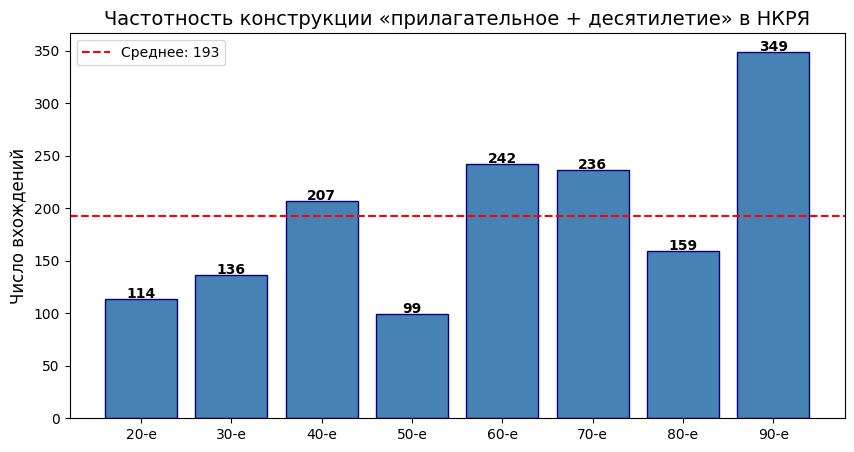

In [134]:
# Воспроизводим Рис. 1 из статьи Бонч-Осмоловской:
# столбчатая диаграмма частотности конструкции по десятилетиям.

labels = list(decade_stats.keys())    # ['20-е', '30-е', ..., '90-е']
values = list(decade_stats.values())  # [35, 38, ..., 57]
mean_val = sum(values) / len(values)  # среднее значение

plt.figure(figsize=(10, 5))

# plt.bar() — столбчатая диаграмма
bars = plt.bar(labels, values, color='steelblue', edgecolor='navy')

# plt.axhline() — горизонтальная линия на уровне среднего.
# y= — координата по оси Y
# linestyle='--' — пунктир
plt.axhline(y=mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.0f}')

plt.title('Частотность конструкции «прилагательное + десятилетие» в НКРЯ', fontsize=14)
plt.ylabel('Число вхождений', fontsize=12)
plt.legend()

# Подписи значений над столбцами
for i, v in enumerate(values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.show()

### Задание 2
Напишите код, который будет создавать из df частотный словать всех коллокатов одного десятилетия.

In [ ]:
from collections import Counter

pass

### Задание 3
Напишите код, который будет создавать частотный словать всех коллокатов с частотностью выше 4 вдождений для всех десятилетий.


*** 20-е ***
  далекие: 8
  золотых: 3
  бурные: 3
  голодные: 3
  ранних: 3
  горький: 3
  золотые: 2
  литературных: 2
  особенно: 2
  ранние: 2

*** 30-е ***
  страшные: 5
  далекие: 4
  ранних: 4
  предвоенных: 3
  ранние: 3
  советские: 2
  последующие: 2
  прошла: 2
  далеких: 2
  роковые: 2

*** 40-е ***
  роковые: 15
  послевоенные: 6
  далекие: 3
  послевоенных: 2
  роковых: 2
  ранних: 2
  военные: 2
  смертной: 1
  страшных: 1
  примерно: 1

*** 50-е ***
  золотые: 5
  золотых: 4
  вознесенский: 2
  поздних: 2
  далекие: 2
  далеких: 2
  изумительно: 2
  железный: 1
  служил: 1
  вознесенского: 1

*** 60-е ***
  поздних: 3
  ранних: 3
  сумасшедшие: 2
  далекие: 2
  славных: 2
  новые: 2
  советские: 2
  бурных: 2
  ранние: 2
  московских: 2

*** 70-е ***
  прошлого: 4
  глухие: 2
  далекие: 2
  городскому: 1
  ранних: 1
  хиппарей: 1
  связанных: 1
  муровские: 1
  далтоновские: 1
  великих: 1

*** 80-е ***
  прошлого: 3
  звездный: 3
  поздние: 2
  особенно: 2
  русские: 

#### Задание 4

Придумайте свою конструкцию из двух слов (например, «прилагательное + война», «наречие + говорить» или что угодно). Сформируйте запрос, получите конкордансы, выведите в DataFrame. Отправьте результат в телеграм.

In [ ]:
# 

---
